In [105]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd

# ATLAS 13TeV data:
# signal = up.open(path + "signal/Events/run_01_decayed_1/tag_1_delphes_events.root")
# sm = up.open("/home/usuario/Madgraph/projects/gg_hh-sm/Events/run_02_decayed_1/tag_1_delphes_events.root")
# bg = up.open("/home/usuario/Madgraph/projects/gg_tth_hdecaylep/Events/run_01/tag_1_delphes_events.root")

# HL-LHC 14TeV data:
signal = up.open("/home/usuario/Madgraph/projects/gg_hh-LQs/signal/Events/HLLHC_14TeV_signal/tag_1_delphes_events.root")
sm = up.open("/home/usuario/Madgraph/projects/gg_hh-sm/Events/HLLHC_14TeV_SM/tag_1_delphes_events.root")
bg = up.open("/home/usuario/Madgraph/projects/gg_tth_hdecaylep/Events/HLLHC_14TeV_bg_hlep/tag_1_delphes_events.root")

signal_tree = signal["Delphes"]
sm_tree = sm["Delphes"]
bg_tree = bg["Delphes"]

vec.register_awkward()

In [106]:
def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

def MissTag_events(data):
    # Me aseguro que data["Jet.BTag"] y data["Jet.TauTag"] sean arrays de numpy solo tomen valores booleanos (0 o 1)
    
    list_bjet = np.unique(ak.flatten(data["Jet.BTag"]))
    list_taujet = np.unique(ak.flatten(data["Jet.TauTag"]))

    # Luego, tomo la catidad de eventos que pasan tanto un filtro de b-tag como de tau-tag
    MissTag_events = ak.sum((data["Jet.BTag"]>0) & (data["Jet.TauTag"]>0))

    return print('Porcentage of double-tagged tau events:', round(MissTag_events / ak.sum(data["Jet.TauTag"] > 0) * 100, 2), '%')

def jets_buildup(data):
    jets = ak.zip({
        "pt": data["Jet.PT"],
        "eta": data["Jet.Eta"],
        "phi": data["Jet.Phi"],
        "mass": data["Jet.Mass"],
        'TauTag': data["Jet.TauTag"],
        'BTag': data["Jet.BTag"],
    }, with_name="Momentum4D")

    return jets

In [107]:
# Incluir las ramas con Missing Energy y Missing Momentum
# extraer phi, eta y pT

tree_keys_to_extract = ["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", 
                         "Jet.BTag","Jet.TauTag", "MissingET.MET", 
                         "MissingET.Phi", "MissingET.Eta"]

data_sl = signal_tree.arrays(tree_keys_to_extract)
data_bg = bg_tree.arrays(tree_keys_to_extract)
data_sm = sm_tree.arrays(tree_keys_to_extract)

miss_tag_sl = MissTag_events(data_sl)
miss_tag_bg = MissTag_events(data_bg)
miss_tag_sm = MissTag_events(data_sm)

miss_tag_sl
miss_tag_bg
miss_tag_sm

Porcentage of double-tagged tau events: 10.88 %
Porcentage of double-tagged tau events: 15.66 %
Porcentage of double-tagged tau events: 10.51 %


NOTA:

Para definir los tags, tambien podemos añadir un criterio de DeltaR, a modo de determinar si los jets tienen un cono de separacion de leptones mayor a 0.4. De este modo, nos aseguramos que los jets están aislados.

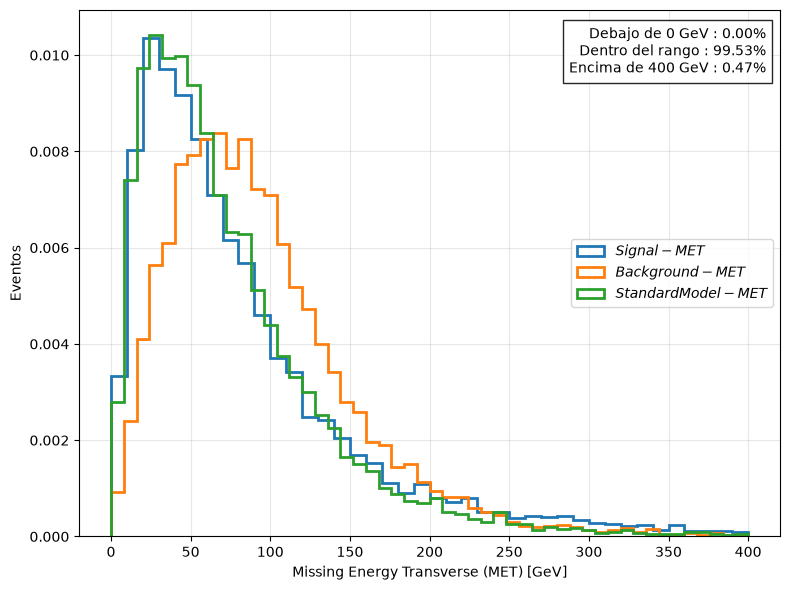

In [108]:
# Distribucion de MET, solo con corte de Cinemática

MET_sl = data_sl["MissingET.MET"]
MET_sm = data_sm["MissingET.MET"]
MET_bg = data_bg["MissingET.MET"]

data = [MET_sl, MET_sm, MET_bg]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(0,400, data)

plt.figure(figsize=(8,6))

texto = (f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"f"Dentro del rango : {p_dentro:.2f}%\n"f"Encima de {lim_sup} GeV : {p_encima:.2f}%")
plt.text(0.98, 0.97,texto,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

# --- Subplot izquierdo: señal ---
plt.hist(MET_sl, bins=40, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - MET$")
plt.hist(MET_bg, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Background - MET$")
plt.hist(MET_sm, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Standard Model - MET$")
plt.xlabel(r"Missing Energy Transverse (MET) [GeV]")
plt.ylabel("Eventos")
plt.legend(loc = 'center right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("MET_distribution.png", dpi=300)
plt.show()

In [120]:
# Parámetros a definir

MET_LowerBond = 50     # GeV
PT_LowerBond = 20       # GeV
Eta_AbsoluteBond = 2.5

# MET Trigger

def MET_trigger(data, MET_lowerbond):

    MET_mask = ak.flatten(data["MissingET.MET"]) > MET_lowerbond

    return MET_mask

MET_mask_sl = MET_trigger(data_sl, MET_LowerBond)
MET_mask_bg = MET_trigger(data_bg, MET_LowerBond)
MET_mask_sm = MET_trigger(data_sm, MET_LowerBond)

data_sl_selected = data_sl[MET_mask_sl]
data_bg_selected = data_bg[MET_mask_bg]
data_sm_selected = data_sm[MET_mask_sm]

# Construyo los jets, con su cuadrivector y los BTag y tautag

jets_sl = jets_buildup(data_sl_selected)
jets_bg = jets_buildup(data_bg_selected)
jets_sm = jets_buildup(data_sm_selected)

# Aplico la mascara de corte cinemático

def cinematic_cut(jet, Pt_lowerBond, Eta_absoluteBond):
    cinematic_mask = (jet.pt > Pt_lowerBond) & (abs(jet.eta) < Eta_absoluteBond)
    return cinematic_mask

cinematic_mask_sl = cinematic_cut(jets_sl, PT_LowerBond, Eta_AbsoluteBond)
cinematic_mask_bg = cinematic_cut(jets_bg, PT_LowerBond, Eta_AbsoluteBond)
cinematic_mask_sm = cinematic_cut(jets_sm, PT_LowerBond, Eta_AbsoluteBond)

jets_sl = jets_sl[cinematic_mask_sl]
jets_bg = jets_bg[cinematic_mask_bg]
jets_sm = jets_sm[cinematic_mask_sm]

# Ahora separo en taus y bs

taus_sl  = jets_sl[(jets_sl['TauTag'] == 1) & (jets_sl['BTag'] == 0)]
bjets_sl = jets_sl[(jets_sl['TauTag'] == 0) & (jets_sl['BTag'] == 1)]

taus_bg  = jets_bg[(jets_bg['TauTag'] == 1) & (jets_bg['BTag'] == 0)]
bjets_bg = jets_bg[(jets_bg['TauTag'] == 0) & (jets_bg['BTag'] == 1)]

taus_sm  = jets_sm[(jets_sm['TauTag'] == 1) & (jets_sm['BTag'] == 0)]
bjets_sm = jets_sm[(jets_sm['TauTag'] == 0) & (jets_sm['BTag'] == 1)]

# Distribuciones de cantidad de taus y bs por evento

N_events_sl = len(ak.sum(jets_sl, axis=1))
N_events_bg = len(ak.sum(jets_bg, axis=1))
N_events_sm = len(ak.sum(jets_sm, axis=1))

N_taus = ak.num(taus_sl, axis=1)
N_bjets = ak.num(bjets_sl, axis=1)

N_taus_BG = ak.num(taus_bg, axis=1)
N_bjets_BG = ak.num(bjets_bg, axis=1)

N_taus_SM = ak.num(taus_sm, axis=1)
N_bjets_SM = ak.num(bjets_sm, axis=1)

print('Cantidad de eventos en la señal:', N_events_sl)
print('Cantidad de eventos en el fondo:', N_events_bg)
print('Cantidad de eventos en el modelo estándar:', N_events_sm)

# Selección de eventos con 2 taus y 2 b-jets

taus_sl  = jets_sl[(jets_sl['TauTag'] == 1) & (jets_sl['BTag'] == 0)]
bjets_sl = jets_sl[(jets_sl['TauTag'] == 0) & (jets_sl['BTag'] == 1)]

taus_bg  = jets_bg[(jets_bg['TauTag'] == 1) & (jets_bg['BTag'] == 0)]
bjets_bg = jets_bg[(jets_bg['TauTag'] == 0) & (jets_bg['BTag'] == 1)]

taus_sm  = jets_sm[(jets_sm['TauTag'] == 1) & (jets_sm['BTag'] == 0)]
bjets_sm = jets_sm[(jets_sm['TauTag'] == 0) & (jets_sm['BTag'] == 1)]


def select_events(taus, bjets):
    mask  = (ak.num(taus) >= 2) & (ak.num(bjets) >= 2)
    taus_cut, bjets_cut = taus[mask], bjets[mask]
    tau1, tau2 = taus_cut[:,0], taus_cut[:,1]
    b1, b2     = bjets_cut[:,0], bjets_cut[:,1]
    return tau1, tau2, b1, b2, taus_cut, bjets_cut

tau1_sl, tau2_sl, b1_sl, b2_sl, taus_cut_sl, bjets_cut_sl = select_events(taus_sl, bjets_sl)
tau1_bg, tau2_bg, b1_bg, b2_bg, taus_cut_bg, bjets_cut_bg = select_events(taus_bg, bjets_bg)
tau1_sm, tau2_sm, b1_sm, b2_sm, taus_cut_sm, bjets_cut_sm = select_events(taus_sm, bjets_sm)

print('Aceptancia de Señal:',round(len(taus_cut_sl)/len(ak.sum(jets_sl, axis=1))*100,2),'%')
print('Aceptancia de Background:', round(len(taus_cut_bg)/len(ak.sum(jets_bg, axis=1))*100,2),'%')
print('Aceptancia de Standard Model:', round(len(taus_cut_sm)/len(ak.sum(jets_sm, axis=1))*100,2),'%')

Cantidad de eventos en la señal: 5975
Cantidad de eventos en el fondo: 7692
Cantidad de eventos en el modelo estándar: 5781
Aceptancia de Señal: 2.31 %
Aceptancia de Background: 2.0 %
Aceptancia de Standard Model: 2.18 %


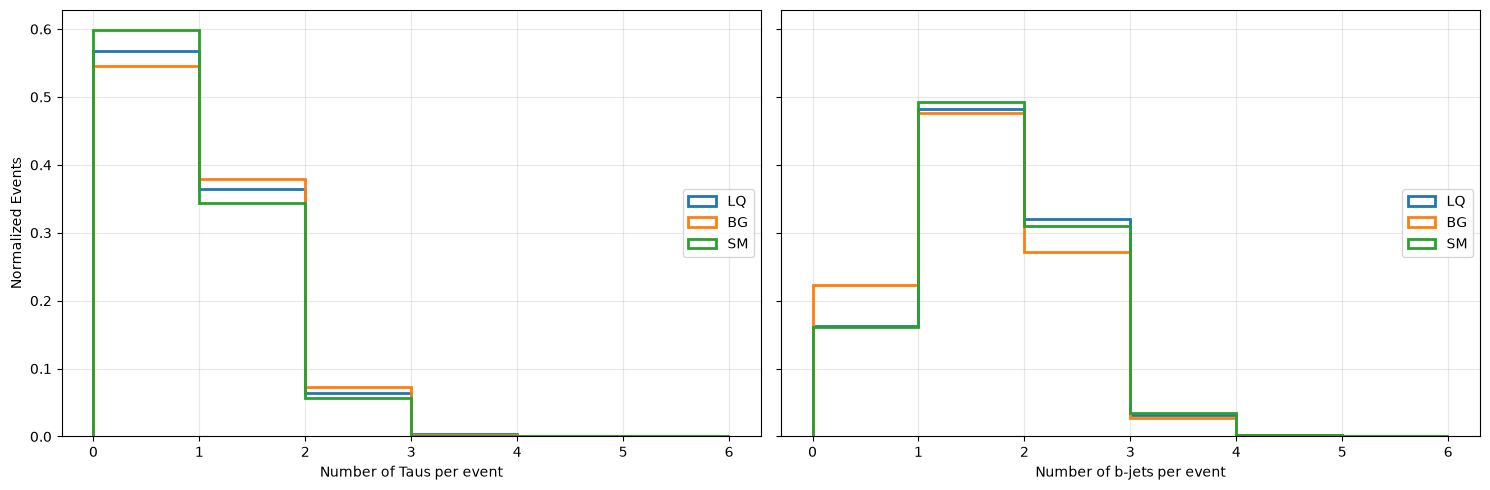

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

# --- Subplot izquierdo: señal ---
axes[0].hist(N_taus, bins=6, density=True, range=(0, 6), histtype="step", linewidth=2, label=r"LQ")
axes[0].hist(N_taus_BG, bins=6, density=True, range=(0, 6), histtype="step", linewidth=2, label=r"BG")
axes[0].hist(N_taus_SM, bins=6, density=True, range=(0, 6), histtype="step", linewidth=2, label=r"SM")
axes[0].set_xlabel(r"Number of Taus per event")
axes[0].set_ylabel("Normalized Events")
axes[0].legend(loc = "center right")
axes[0].grid(alpha=0.3)

axes[1].hist(N_bjets, bins=6, density=True, range=(0, 6), histtype="step", linewidth=2, label=r"LQ")
axes[1].hist(N_bjets_BG, bins=6, density=True, range=(0, 6), histtype="step", linewidth=2, label=r"BG")
axes[1].hist(N_bjets_SM, bins=6, density=True, range=(0, 6), histtype="step", linewidth=2, label=r"SM")
axes[1].set_xlabel(r"Number of b-jets per event")
axes[1].legend(loc = "center right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Higgs_pT_distribution.png", dpi=300)
plt.show()

In [111]:
# Construyo los cuatrivectores de los pares de higgs para LQ y SM
# Los cuadrivectores para BG no los puedo reconstruir a nivel Rec debido 
# a que los bosones W decaen a lep y neutrino.

# Ademas, estoy reconstruyendo solo los higgs 'visibles', de modo que
# el pT reconstruido no es identicamente el pT completo del Higgs

LQ_hlep = tau1_sl + tau2_sl
LQ_hhad = b1_sl + b2_sl

SM_hlep = tau1_sm + tau2_sm
SM_hhad = b1_sm + b2_sm

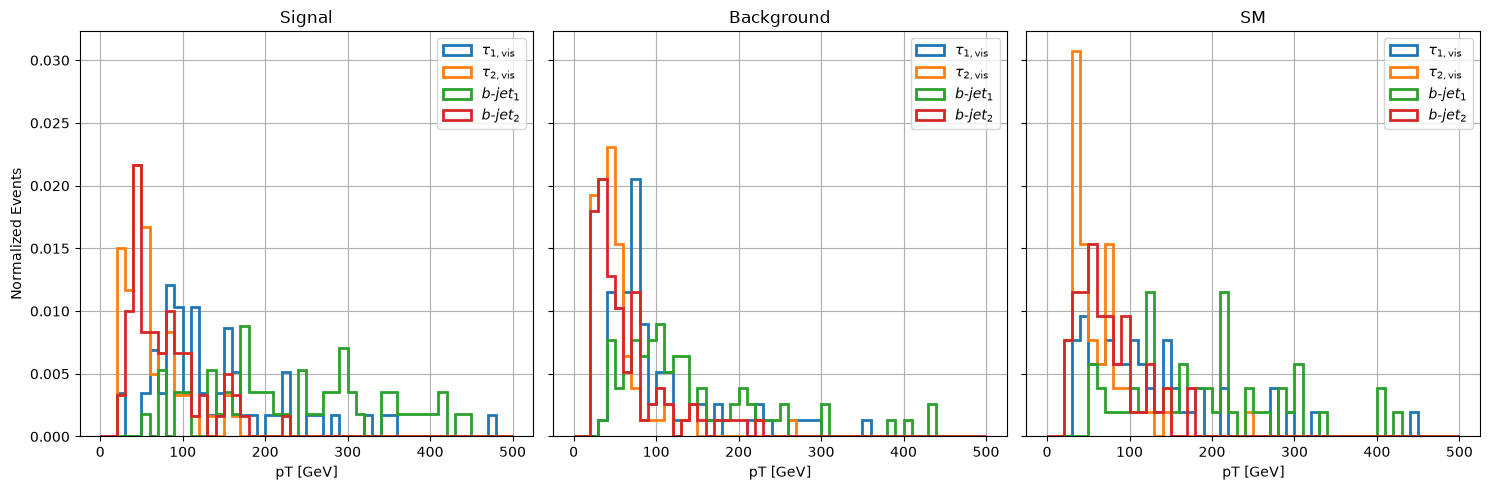

In [112]:
sets = [("Signal", tau1_sl, tau2_sl, b1_sl, b2_sl),
        ("Background", tau1_bg, tau2_bg, b1_bg, b2_bg),
        ("SM", tau1_sm, tau2_sm, b1_sm, b2_sm)]

labels = [r"$\tau_{1, \text{vis}}$", r"$\tau_{2, \text{vis}}$", r"$b\text{-}jet_1$", r"$b\text{-}jet_2$"]
kw = dict(bins=50, range=(0,500), density=True, histtype="step", linewidth=2)

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[0].hist(ak.to_numpy(tau1_sl.pt), label=labels[0], **kw)
axes[0].hist(ak.to_numpy(tau2_sl.pt), label=labels[1], **kw)
axes[0].hist(ak.to_numpy(b1_sl.pt), label=labels[2], **kw)
axes[0].hist(ak.to_numpy(b2_sl.pt), label=labels[3], **kw)
axes[0].set_title("Signal")
axes[0].set_ylabel("Normalized Events")
axes[0].set_xlabel("pT [GeV]")
axes[0].legend()

axes[1].hist(ak.to_numpy(tau1_bg.pt), label=labels[0], **kw)
axes[1].hist(ak.to_numpy(tau2_bg.pt), label=labels[1], **kw)
axes[1].hist(ak.to_numpy(b1_bg.pt), label=labels[2], **kw)
axes[1].hist(ak.to_numpy(b2_bg.pt), label=labels[3], **kw)
axes[1].set_title("Background")
axes[1].set_xlabel("pT [GeV]")
axes[1].legend()

axes[2].hist(ak.to_numpy(tau1_sm.pt), label=labels[0], **kw)
axes[2].hist(ak.to_numpy(tau2_sm.pt), label=labels[1], **kw)
axes[2].hist(ak.to_numpy(b1_sm.pt), label=labels[2], **kw)
axes[2].hist(ak.to_numpy(b2_sm.pt), label=labels[3], **kw)
axes[2].set_title("SM")
axes[2].set_xlabel("pT [GeV]")
axes[2].legend()

for ax in axes:
        ax.grid()

fig.tight_layout()
fig.savefig("pt_distribution.png", dpi=300)
plt.show()

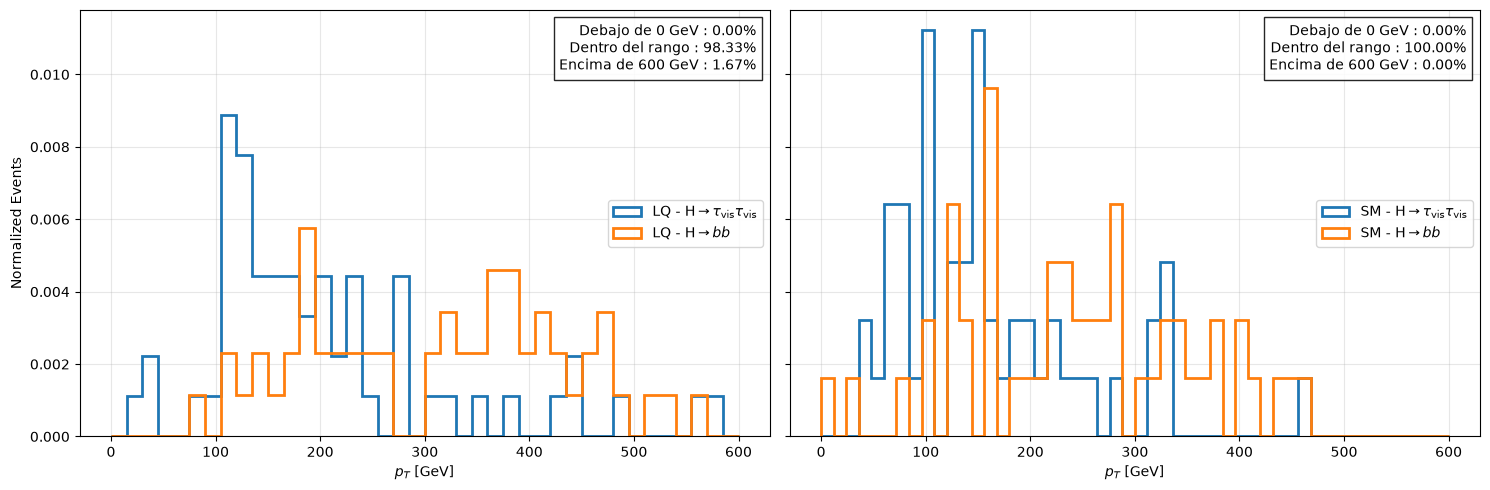

In [113]:
data_LQ = [LQ_hlep.pt, LQ_hhad.pt]
data_SM = [SM_hlep.pt, SM_hhad.pt]

lim_inf_LQ, lim_sup_LQ, p_debajo_LQ, p_dentro_LQ, p_encima_LQ = calculo_rangos(0,600, data_LQ)
lim_inf_SM, lim_sup_SM, p_debajo_SM, p_dentro_SM, p_encima_SM = calculo_rangos(0,600, data_SM)

fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

texto1 = (
    f"Debajo de {lim_inf_LQ} GeV : {p_debajo_LQ:.2f}%\n"
    f"Dentro del rango : {p_dentro_LQ:.2f}%\n"
    f"Encima de {lim_sup_LQ} GeV : {p_encima_LQ:.2f}%"
)

texto2 = (
    f"Debajo de {lim_inf_SM} GeV : {p_debajo_SM:.2f}%\n"
    f"Dentro del rango : {p_dentro_SM:.2f}%\n"
    f"Encima de {lim_sup_SM} GeV : {p_encima_SM:.2f}%"
)

axes[0].text(0.98, 0.97,texto1,transform=axes[0].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[1].text(0.98, 0.97,texto2,transform=axes[1].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

# --- Subplot izquierdo: señal ---
axes[0].hist(ak.to_numpy(LQ_hlep.pt), bins=40, density=True, range=(lim_inf_LQ, lim_sup_LQ), histtype="step", linewidth=2, label=r"LQ - H$\to\tau_{\text{vis}}\tau_{\text{vis}}$")
axes[0].hist(ak.to_numpy(LQ_hhad.pt), bins=40, density=True, range=(lim_inf_LQ, lim_sup_LQ), histtype="step", linewidth=2, label=r"LQ - H$\to bb$")
axes[0].set_xlabel(r"$p_T$ [GeV]")
axes[0].set_ylabel("Normalized Events")
axes[0].legend(loc = "center right")
axes[0].grid(alpha=0.3)

axes[1].hist(ak.to_numpy(SM_hlep.pt), bins=50, density=True, range=(lim_inf_SM, lim_sup_SM), histtype="step", linewidth=2, label=r"SM - H$\to\tau_{\text{vis}}\tau_{\text{vis}}$")
axes[1].hist(ak.to_numpy(SM_hhad.pt), bins=50, density=True, range=(lim_inf_SM, lim_sup_SM), histtype="step", linewidth=2, label=r"SM - H$\to bb$")
axes[1].set_xlabel(r"$p_T$ [GeV]")
axes[1].legend(loc = "center right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Higgs_pT_distribution.png", dpi=300)
plt.show()

In [114]:
# Distribucion de masas invariante de los pares tau-tau y b-b

LQ_m_tautau = LQ_hlep.mass
LQ_m_bb     = LQ_hhad.mass
LQ_m_hh     = (LQ_hlep + LQ_hhad).mass

SM_m_tautau = SM_hlep.mass
SM_m_bb     = SM_hhad.mass
SM_m_hh     = (SM_hlep + SM_hhad).mass

BG_m_tautau = (tau1_bg + tau2_bg).mass
BG_m_bb     = (b1_bg + b2_bg).mass
BG_m_hh     = (tau1_bg + tau2_bg + b1_bg + b2_bg).mass

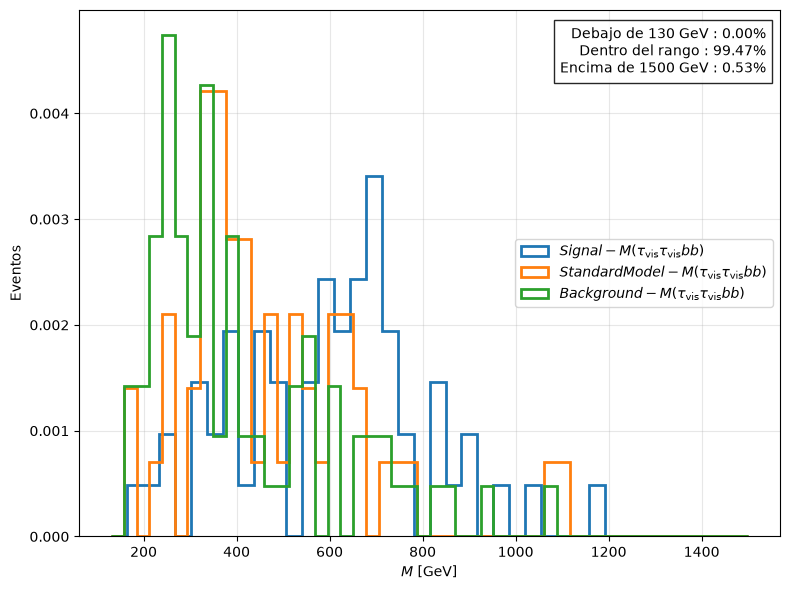

In [115]:
data = [LQ_m_hh, SM_m_hh, BG_m_hh]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(130,1500, data)

plt.figure(figsize=(8,6))

texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

# --- Subplot izquierdo: señal ---
plt.hist(LQ_m_hh, bins=40, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - M(\tau_{\text{vis}} \tau_{\text{vis}} b b)$")
plt.hist(SM_m_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Standard Model - M(\tau_{\text{vis}} \tau_{\text{vis}} b b)$")
plt.hist(BG_m_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Background - M(\tau_{\text{vis}} \tau_{\text{vis}} b b)$")
plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("InvariantMass_distribution.png", dpi=300)
plt.show()

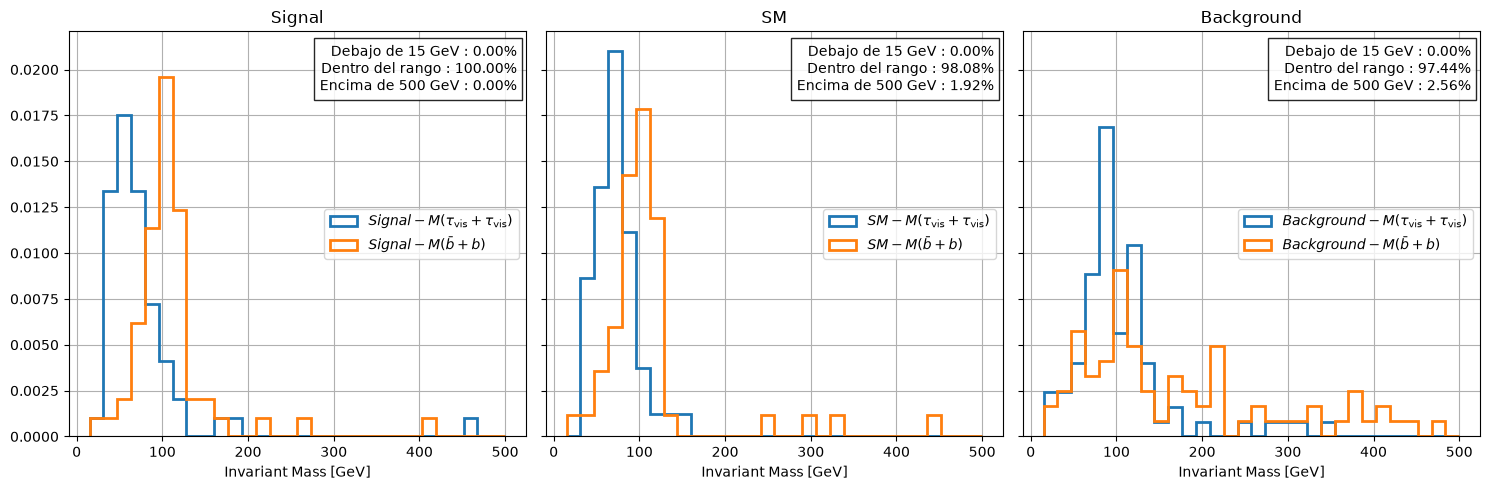

In [116]:
data0 = [LQ_m_tautau, LQ_m_bb]
data1 = [SM_m_tautau, SM_m_bb]
data2 = [BG_m_tautau, BG_m_bb]

lim_inf_0, lim_sup_0, p_debajo_0, p_dentro_0, p_encima_0 = calculo_rangos(15,500, data0)
lim_inf_1, lim_sup_1, p_debajo_1, p_dentro_1, p_encima_1 = calculo_rangos(15,500, data1)
lim_inf_2, lim_sup_2, p_debajo_2, p_dentro_2, p_encima_2 = calculo_rangos(15,500, data2)


fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

texto0 = (f"Debajo de {lim_inf_0} GeV : {p_debajo_0:.2f}%\n"f"Dentro del rango : {p_dentro_0:.2f}%\n"f"Encima de {lim_sup_0} GeV : {p_encima_0:.2f}%")
texto1 = (f"Debajo de {lim_inf_1} GeV : {p_debajo_1:.2f}%\n"f"Dentro del rango : {p_dentro_1:.2f}%\n"f"Encima de {lim_sup_1} GeV : {p_encima_1:.2f}%")
texto2 = (f"Debajo de {lim_inf_2} GeV : {p_debajo_2:.2f}%\n"f"Dentro del rango : {p_dentro_2:.2f}%\n"f"Encima de {lim_sup_2} GeV : {p_encima_2:.2f}%")

axes[0].text(0.98, 0.97,texto0,transform=axes[0].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[1].text(0.98, 0.97,texto1,transform=axes[1].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[2].text(0.98, 0.97,texto2,transform=axes[2].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

axes[0].hist(LQ_m_tautau, bins=30, density=True, range=(lim_inf_0, lim_sup_0), histtype="step", linewidth=2, label=r"$Signal - M(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[0].hist(LQ_m_bb, bins=30, density=True, range=(lim_inf_0, lim_sup_0), histtype="step", linewidth=2, label=r"$Signal - M(\bar{b} + b)$")
axes[0].set_title("Signal")
axes[0].set_xlabel("Invariant Mass [GeV]")
axes[0].legend(loc = 'center right')

axes[1].hist(SM_m_tautau, bins=30, density=True, range=(lim_inf_1, lim_sup_1), histtype="step", linewidth=2, label=r"$SM - M(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[1].hist(SM_m_bb, bins=30, density=True, range=(lim_inf_1, lim_sup_1), histtype="step", linewidth=2, label=r"$SM - M(\bar{b} + b)$")
axes[1].set_title("SM")
axes[1].set_xlabel("Invariant Mass [GeV]")
axes[1].legend(loc = 'center right')

axes[2].hist(BG_m_tautau, bins=30, density=True, range=(lim_inf_2, lim_sup_2), histtype="step", linewidth=2, label=r"$Background - M(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[2].hist(BG_m_bb, bins=30, density=True, range=(lim_inf_2, lim_sup_2), histtype="step", linewidth=2, label=r"$Background - M(\bar{b} + b)$")
axes[2].set_title("Background")
axes[2].set_xlabel("Invariant Mass [GeV]")
axes[2].legend(loc = 'center right')

for ax in axes:
        ax.grid()

fig.tight_layout()
plt.savefig("MassControl.png", dpi=300)
plt.show()

In [117]:
# Distribución de DeltaR entre los pares tau-tau y b-b

DeltaR_tautau = tau1_sl.deltaR(tau2_sl)
DeltaR_bb = b1_sl.deltaR(b2_sl)

DeltaR_tautau_SM = tau1_sm.deltaR(tau2_sm)
DeltaR_bb_SM = b1_sm.deltaR(b2_sm)

DeltaR_tautau_BG = tau1_bg.deltaR(tau2_bg)
DeltaR_bb_BG = b1_bg.deltaR(b2_bg)


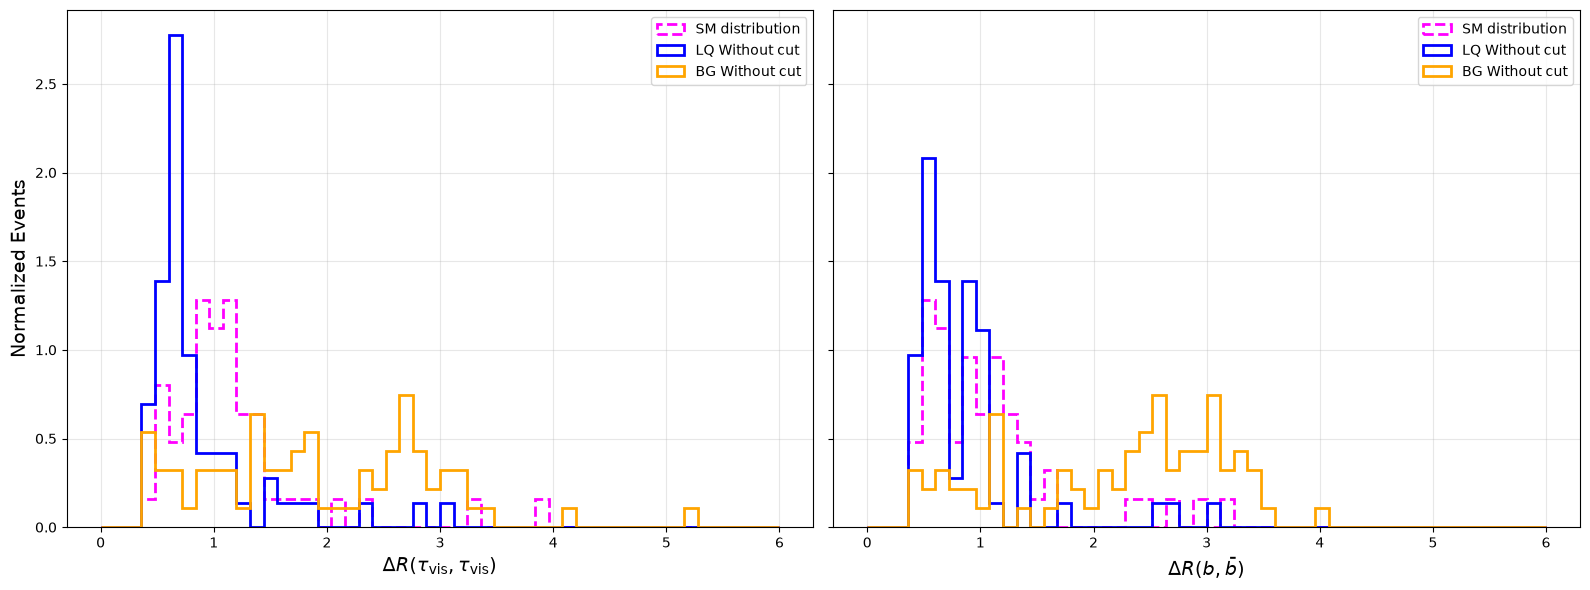

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# ==========================================================
# Primer gráfico
# ==========================================================

ax1.hist(DeltaR_tautau_SM,bins=50,range=(0,6),histtype="step", density = True,color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax1.hist(DeltaR_tautau,bins=50,range=(0,6),histtype="step", density = True,color="blue",linewidth=2,label="LQ Without cut")

ax1.hist(DeltaR_tautau_BG,bins=50,range=(0,6),histtype="step", density = True,color="orange",linewidth=2,label="BG Without cut")

ax1.set_xlabel(r"$\Delta R(\tau_{\text{vis}},\tau_{\text{vis}})$", fontsize=14)
ax1.set_ylabel("Normalized Events", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# ==========================================================
# Segundo gráfico
# ==========================================================

ax2.hist(DeltaR_bb_SM,bins=50,range=(0,6),histtype="step", density = True,color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax2.hist(DeltaR_bb,bins=50,range=(0,6),histtype="step", density = True,color="blue",linewidth=2,label="LQ Without cut")

ax2.hist(DeltaR_bb_BG,bins=50,range=(0,6),histtype="step", density = True,color="orange",linewidth=2,label="BG Without cut")

ax2.set_xlabel(r"$\Delta R(b,\bar{b})$", fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig("DeltaR_distribution.png", dpi=300)

plt.show()

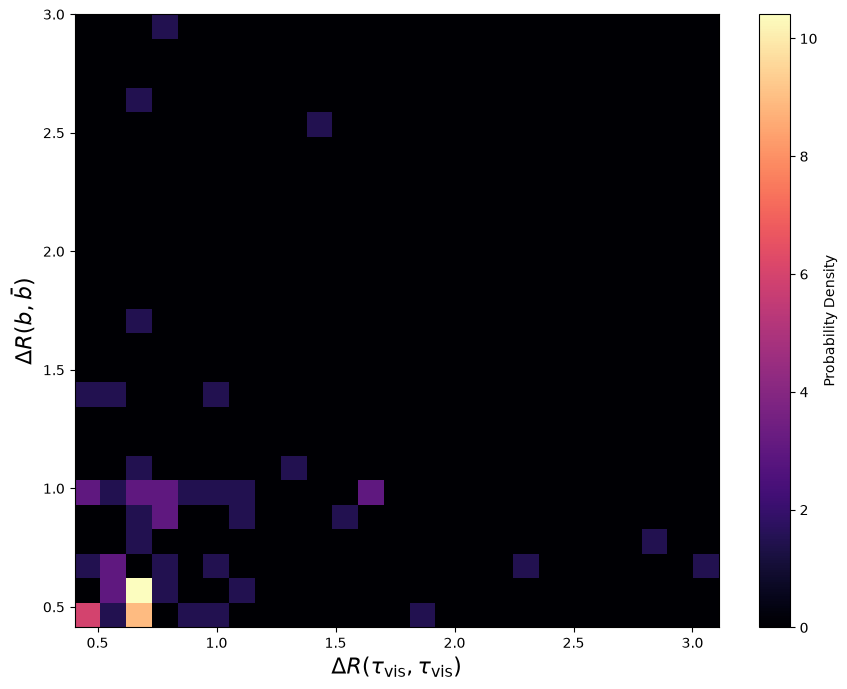

In [119]:
# Grafico 2D de DeltaR(tau tau) vs DeltaR(b b)

plt.figure(figsize=(9,7))

plt.hist2d(ak.to_numpy(DeltaR_tautau), ak.to_numpy(DeltaR_bb), bins=25, cmap="magma", density=True)
# plt.hist2d(DeltaR_tautau_SM, DeltaR_bb_SM, bins=50, cmap="viridis", density=True)

plt.colorbar(label="Probability Density")
plt.xlabel(r"$\Delta R(\tau_{\text{vis}},\tau_{\text{vis}})$", fontsize=16)
plt.ylabel(r"$\Delta R(b,\bar{b})$", fontsize=16)

plt.tight_layout()
plt.savefig("2D-DeltaR_distribution.png", dpi=300)
plt.show()